In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Create a CNN to classify the images

In [2]:
n_images = 2000
img_size = 30

# initialize tensor containing images
images = torch.zeros(n_images,1,img_size,img_size)
labels = torch.zeros(n_images,1)

for i in range(n_images):

  # and add noise
  G  = np.random.uniform(0,1,(img_size,img_size))

  # add a random bar randomly
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))
  if np.random.randn()>0:
    G[i1:i1+i2,] = 1 # horizontal
  else:
    G[:,i1:i1+i2] = 1 # vertical
    labels[i] = 1
  
  # convert to tensor and add to the tensor from numpy array
  images[i,:,:,:] = torch.Tensor(G).view(1,img_size,img_size)

# scale images between 0 and 1
images = (images - images.min()) / (images.max() - images.min())

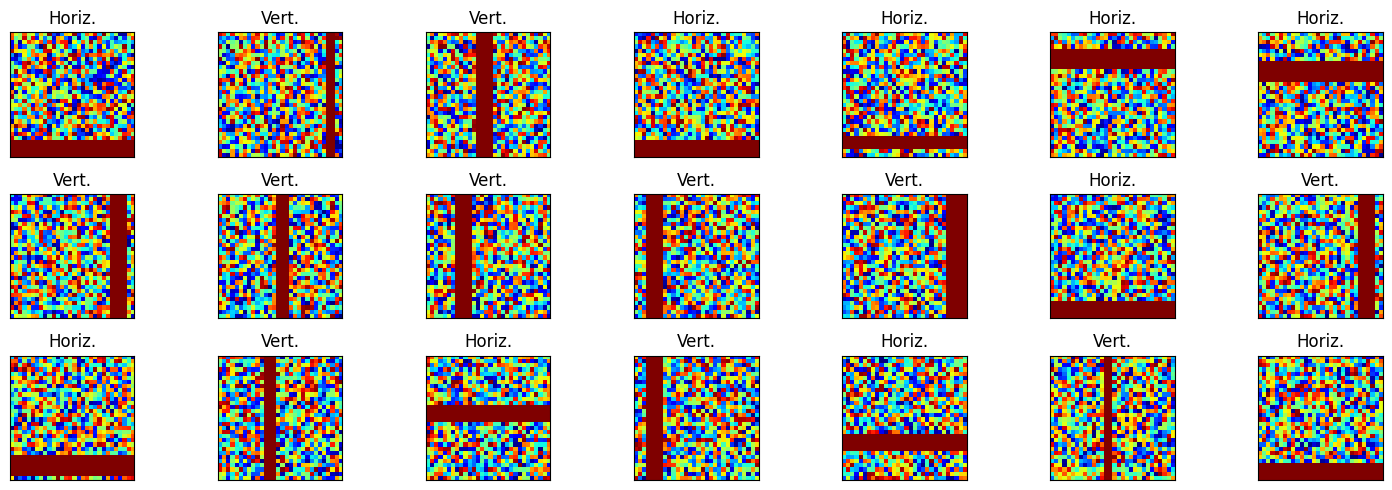

In [3]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,5))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(n_images)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=0,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='upper')
  
  title = 'Horiz.' if labels[whichpic].item()==0 else 'Vert.'
  ax.set_title(title)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

In [4]:
data_train, data_val_test, labels_train, labels_val_test = train_test_split(images, labels, test_size=0.2, random_state=42) 
data_test, data_val, labels_test, labels_val = train_test_split(data_val_test, labels_val_test, test_size=0.5, random_state=42)

batch_size = 32
train_dataloader = DataLoader(TensorDataset(data_train, labels_train), batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(TensorDataset(data_val, labels_val), batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(TensorDataset(data_test, labels_test), batch_size=batch_size, shuffle=False)

# check out a sample
images_tl, labels_tl = next(iter(train_dataloader))
print(f"Image batch shape: {images_tl.shape}")
print(f"Label batch shape: {labels_tl.shape}")
images_tl.min(), images_tl.max() # check the range of pixel values (should be between 0 and 1 due to normalization)

Image batch shape: torch.Size([32, 1, 30, 30])
Label batch shape: torch.Size([32, 1])


(tensor(0.0001), tensor(1.))

In [5]:
class CNN_Edge(nn.Module):
    def __init__(self, num_channels=(4, 8)):
        super().__init__()
        # With k=3, padding=1, stride = 1, we came with size_in = size_out
        self.encoder = nn.Sequential(
            # input size = (1, 30, 30) for FashionMNIST
            nn.Conv2d(in_channels=1, out_channels=num_channels[0], kernel_size=3, stride=1, padding=1), # output size = np.floor((30 - 3 + 2*1) / 1) + 1 = 30
            nn.BatchNorm2d(num_features=num_channels[0]),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((30 - 2) / 2) + 1 = 15

            nn.Conv2d(in_channels=num_channels[0], out_channels=num_channels[1], kernel_size=3, stride=1, padding=1), # output size = np.floor((15 - 3 + 2*1) / 1) + 1 = 15
            nn.BatchNorm2d(num_features=num_channels[1]), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((15 - 2) / 2) + 1 = 7
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # flatten the output of the convolutional layers to feed into the fully connected layers
            nn.Linear(in_features=num_channels[1]*7*7, out_features=32),
            nn.LeakyReLU(),
            nn.Dropout(0.5), # add dropout to prevent overfitting
            nn.Linear(in_features=32, out_features=1) # 1 output for binary classification
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = CNN_Edge(num_channels=(4, 8))
summary(model, input_size=(1, 30, 30))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 30, 30]              40
       BatchNorm2d-2            [-1, 4, 30, 30]               8
         LeakyReLU-3            [-1, 4, 30, 30]               0
         MaxPool2d-4            [-1, 4, 15, 15]               0
            Conv2d-5            [-1, 8, 15, 15]             296
       BatchNorm2d-6            [-1, 8, 15, 15]              16
         LeakyReLU-7            [-1, 8, 15, 15]               0
         MaxPool2d-8              [-1, 8, 7, 7]               0
           Flatten-9                  [-1, 392]               0
           Linear-10                   [-1, 32]          12,576
        LeakyReLU-11                   [-1, 32]               0
          Dropout-12                   [-1, 32]               0
           Linear-13                    [-1, 1]              33
Total params: 12,969
Trainable params: 

In [6]:
# test one forward pass to see the print statements in action
model = CNN_Edge(num_channels=(4, 8))
loss_fn = nn.BCEWithLogitsLoss() # it implements both sigmoid and the binary cross-entropy loss
images, labels = next(iter(train_dataloader))
output = model(images)
predicted_classes = (torch.sigmoid(output) > 0.5).float()
loss = loss_fn(output, labels.float())
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 1, 30, 30])
Output shape: torch.Size([32, 1])
Labels shape: torch.Size([32, 1])
Loss: 0.7442018389701843


In [7]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, y)

        # Update training loss and accuracy
        train_loss += loss.item()
        train_accuracy += (torch.sigmoid(outputs) > 0.5).float().eq(y).sum().item() # eq(y) counts the number of correct predictions

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          ):

    train_losses_epochs = []
    val_losses_epochs = []
    train_accuracy_epochs = []
    val_accuracy_epochs = []

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_accuracy = train_accuracy / len(train_dataloader.dataset)
        train_losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_accuracy)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, y)

                val_loss += loss.item()
                val_accuracy += (torch.sigmoid(outputs) > 0.5).float().eq(y).sum().item()

        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_accuracy = val_accuracy / len(val_dataloader.dataset)
        val_losses_epochs.append(avg_val_loss)
        val_accuracy_epochs.append(avg_val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, "
            f"Train Accuracy: {avg_train_accuracy:.4f}, "
            f"Val Accuracy: {avg_val_accuracy:.4f}"
        )

    return train_losses_epochs, val_losses_epochs, train_accuracy_epochs, val_accuracy_epochs

In [8]:
loss_fn = nn.BCEWithLogitsLoss()
epochs = 10

model = CNN_Edge(num_channels=(4, 8))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loss, val_loss, train_accuracy, val_accuracy = train(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.6888, Val Loss: 0.6679, Train Accuracy: 0.5463, Val Accuracy: 0.6650
Epoch [2/10], Train Loss: 0.5887, Val Loss: 0.4530, Train Accuracy: 0.7106, Val Accuracy: 0.9100
Epoch [3/10], Train Loss: 0.2933, Val Loss: 0.1035, Train Accuracy: 0.9181, Val Accuracy: 0.9950
Epoch [4/10], Train Loss: 0.1041, Val Loss: 0.0232, Train Accuracy: 0.9769, Val Accuracy: 1.0000
Epoch [5/10], Train Loss: 0.0481, Val Loss: 0.0213, Train Accuracy: 0.9938, Val Accuracy: 1.0000
Epoch [6/10], Train Loss: 0.0268, Val Loss: 0.0046, Train Accuracy: 0.9969, Val Accuracy: 1.0000
Epoch [7/10], Train Loss: 0.0215, Val Loss: 0.0030, Train Accuracy: 0.9975, Val Accuracy: 1.0000
Epoch [8/10], Train Loss: 0.0170, Val Loss: 0.0181, Train Accuracy: 0.9975, Val Accuracy: 0.9950
Epoch [9/10], Train Loss: 0.0116, Val Loss: 0.0035, Train Accuracy: 0.9988, Val Accuracy: 1.0000
Epoch [10/10], Train Loss: 0.0084, Val Loss: 0.0008, Train Accuracy: 0.9994, Val Accuracy: 1.0000


In [9]:
# get the final test accuracy
model.eval()
test_loss = 0.0
test_accuracy = 0.0
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        loss = loss_fn(outputs, y)

        test_loss += loss.item()
        test_accuracy += (torch.sigmoid(outputs) > 0.5).float().eq(y).sum().item()
        
# calculate the average test loss and accuracy
test_loss /= len(test_dataloader)
test_accuracy /= len(test_dataloader.dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0023
Test Accuracy: 1.0000


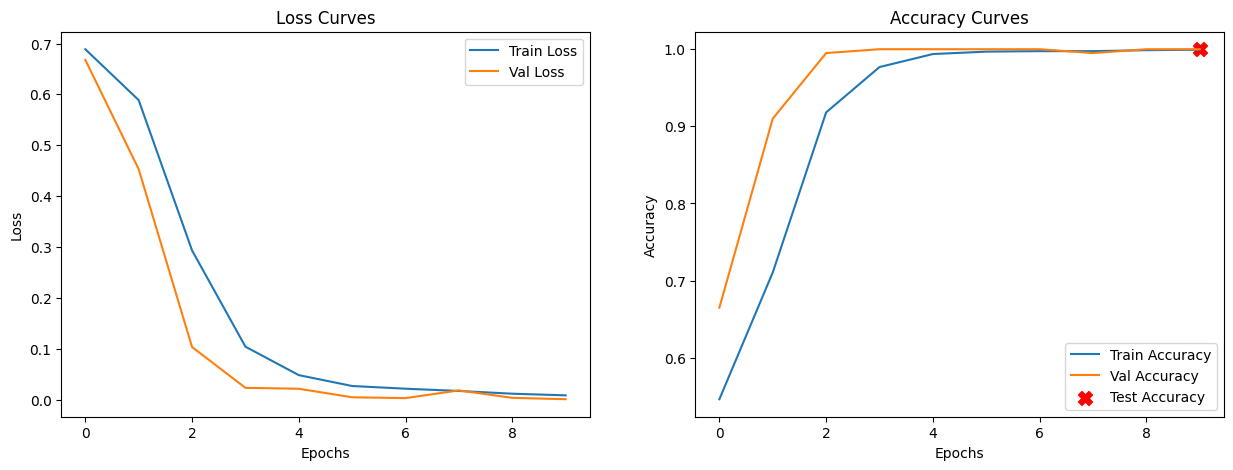

In [10]:
# plot loss and accuracy curves
plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Val Accuracy")
plt.scatter(epochs-1, test_accuracy, label="Test Accuracy", color="red", marker="X", s=100)
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# there is a small overfitting, so this means, we could have stopped training earlier, but we trained for 15 epochs to see the curves more clearly. 
# We could also add more regularization (e.g. dropout, weight decay) to reduce overfitting.

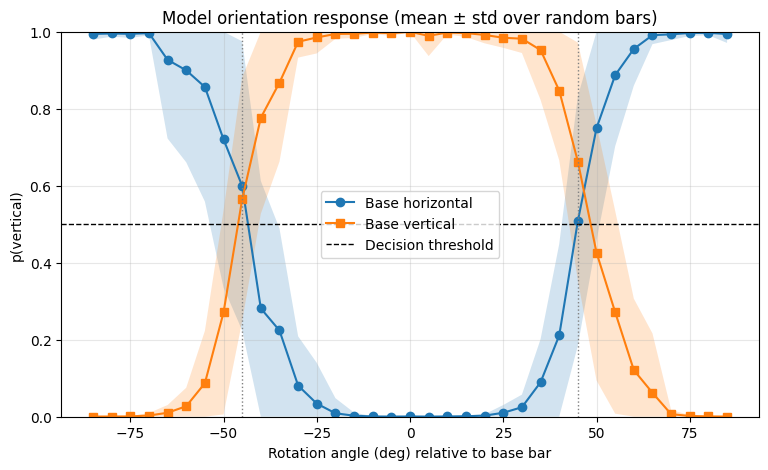

Horizontal base (selected angles):
-85 deg -> 0.994
-65 deg -> 0.927
-45 deg -> 0.600
-25 deg -> 0.034
 -5 deg -> 0.000
 15 deg -> 0.001
 35 deg -> 0.090
 55 deg -> 0.887
 75 deg -> 0.997

Vertical base (selected angles):
-85 deg -> 0.000
-65 deg -> 0.010
-45 deg -> 0.565
-25 deg -> 0.985
 -5 deg -> 0.996
 15 deg -> 0.997
 35 deg -> 0.952
 55 deg -> 0.271
 75 deg -> 0.002


In [19]:
# Orientation response diagnostic: both bases + averaging
from skimage.transform import rotate

def make_bar(img_size=30, thickness=3, orientation='horizontal', noise=True):
    G = np.random.uniform(0,1,(img_size,img_size)) if noise else np.zeros((img_size,img_size))
    i1 = np.random.randint(6, img_size-6)
    if orientation == 'horizontal':
        G[i1:i1+thickness, :] = 1.0
    else:
        G[:, i1:i1+thickness] = 1.0
    return G

def rotated_sample(angle_deg, base='horizontal', img_size=30, thickness=3, noise=True):
    G = make_bar(img_size=img_size, thickness=thickness, orientation=base, noise=noise)
    Grot = rotate(
        G, angle=angle_deg, resize=False, order=1,
        mode='constant', cval=0.0, preserve_range=True
    )
    Grot = np.clip(Grot, 0, 1).astype(np.float32)
    return torch.tensor(Grot).view(1,1,img_size,img_size)

def eval_curve(base='horizontal', angles=None, n_trials=50, noise=True):
    if angles is None:
        angles = np.arange(-85, 86, 5)
    mean_probs = []
    std_probs = []

    model.eval()
    with torch.no_grad():
        for ang in angles:
            trial_probs = []
            for _ in range(n_trials):
                x = rotated_sample(ang, base=base, img_size=img_size, thickness=3, noise=noise)
                p_vert = torch.sigmoid(model(x)).item()
                trial_probs.append(p_vert)
            mean_probs.append(np.mean(trial_probs))
            std_probs.append(np.std(trial_probs))

    return np.array(mean_probs), np.array(std_probs)

angles = np.arange(-85, 86, 5)
mean_h, std_h = eval_curve(base='horizontal', angles=angles, n_trials=50, noise=True)
mean_v, std_v = eval_curve(base='vertical',   angles=angles, n_trials=50, noise=True)

plt.figure(figsize=(9,5))
plt.plot(angles, mean_h, 'o-', label='Base horizontal')
plt.fill_between(angles, np.clip(mean_h-std_h,0,1), np.clip(mean_h+std_h,0,1), alpha=.2)

plt.plot(angles, mean_v, 's-', label='Base vertical')
plt.fill_between(angles, np.clip(mean_v-std_v,0,1), np.clip(mean_v+std_v,0,1), alpha=.2)

plt.axhline(0.5, color='k', ls='--', lw=1, label='Decision threshold')
plt.axvline(45, color='gray', ls=':', lw=1)
plt.axvline(-45, color='gray', ls=':', lw=1)
plt.xlabel('Rotation angle (deg) relative to base bar')
plt.ylabel('p(vertical)')
plt.title('Model orientation response (mean ± std over random bars)')
plt.ylim(0,1)
plt.grid(True, alpha=.3)
plt.legend()
plt.show()

print('Horizontal base (selected angles):')
for a, p in zip(angles[::4], mean_h[::4]):
    print(f'{a:>3} deg -> {p:.3f}')

print('\nVertical base (selected angles):')
for a, p in zip(angles[::4], mean_v[::4]):
    print(f'{a:>3} deg -> {p:.3f}')